In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src.dataset import CharTokenizer, split_data
from src.models import create_deep_mlp
from src.nn import Tanh
from src.diagnostics import (
    plot_activation_distribution,
    plot_gradient_distribution,
    plot_weights_gradient_distribution,
    plot_update_to_data_ratio
)

# Create data sets
words = open("data/names.txt", "r").read().splitlines()
tokenizer = CharTokenizer(words)
vacab_size = len(tokenizer.itos)
block_size = 3
(Xtr, Ytr), (Xdev, Ydev), (Xtest, Ytest) = split_data(words, tokenizer, block_size)
print(f"Xtr: {Xtr.shape} Ytr {Ytr.shape}")

# Create model
g = torch.Generator().manual_seed(42)
model = create_deep_mlp(
    embedding_size=10, 
    vacab_size=vacab_size, 
    block_size=block_size, 
    hidden_dim=100, 
    num_hidden_layers=4, 
    generator=g)
print(f"Total params: {sum(p.nelement() for p in model.parameters())}") # number of parameters in total

Xtr: torch.Size([182778, 3]) Ytr torch.Size([182778])
Total params: 47024


In [7]:
batch_size = 64
max_steps = 200000

ud = [] # update to date ratio change history
lossi = [] #log loss change history

for step in range(max_steps):
    # 1. select a random mini-batch from training data set
    batch_idxes = torch.randint(0, Xtr.shape[0], (batch_size,))

    # 2. prepare training data with embeddings
    # x: (batch_size, block_size * emb_size) 
    # y: (batch_size,)
    x = Xtr[batch_idxes]
    y = Ytr[batch_idxes]

    # 3. forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    # 4. backward pass
    for layer in model.layers:
        layer.out.retain_grad() #Retain grad for non-leaf node, debug only
    for p in model.parameters():
        p.grad = None
    loss.backward()

    # 5. optimize with learning rate decay
    lr = 0.1 if step < 150000 else 0.01
    for p in model.parameters():
        p.data -= lr * p.grad

    # track stats
    if step % 10000 == 0: # print every once in a while
        print(f'{step:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append( [((lr*p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])

    if step >= 1000:
        break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3107


Layer 0 (Tanh) | Mean: -0.00 | Std: 0.65 | Saturated:  2.55%
Layer 1 (Tanh) | Mean: +0.00 | Std: 0.64 | Saturated:  2.61%
Layer 2 (Tanh) | Mean: -0.00 | Std: 0.65 | Saturated:  2.25%
Layer 3 (Tanh) | Mean: +0.00 | Std: 0.65 | Saturated:  2.17%
Layer 4 (Tanh) | Mean: +0.01 | Std: 0.65 | Saturated:  2.45%


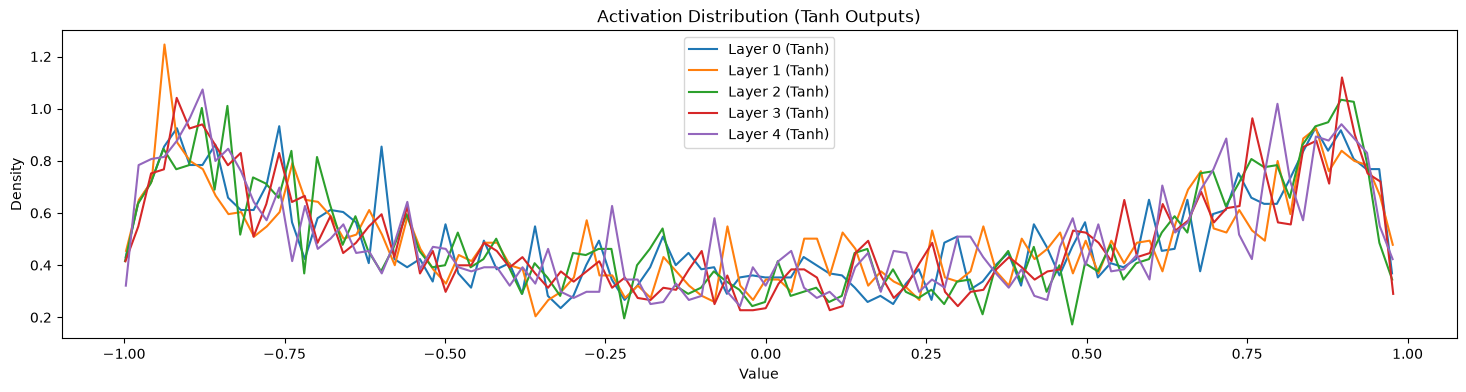

In [8]:
# visualize histograms
plot_activation_distribution(model)

Layer 0 (Tanh grad) | Mean: -2.910383e-12 | Std: 2.172685e-03
Layer 1 (Tanh grad) | Mean: -3.492460e-12 | Std: 1.956308e-03
Layer 2 (Tanh grad) | Mean: +6.475602e-12 | Std: 1.877133e-03
Layer 3 (Tanh grad) | Mean: -6.839400e-12 | Std: 1.693045e-03
Layer 4 (Tanh grad) | Mean: +0.000000e+00 | Std: 1.629229e-03


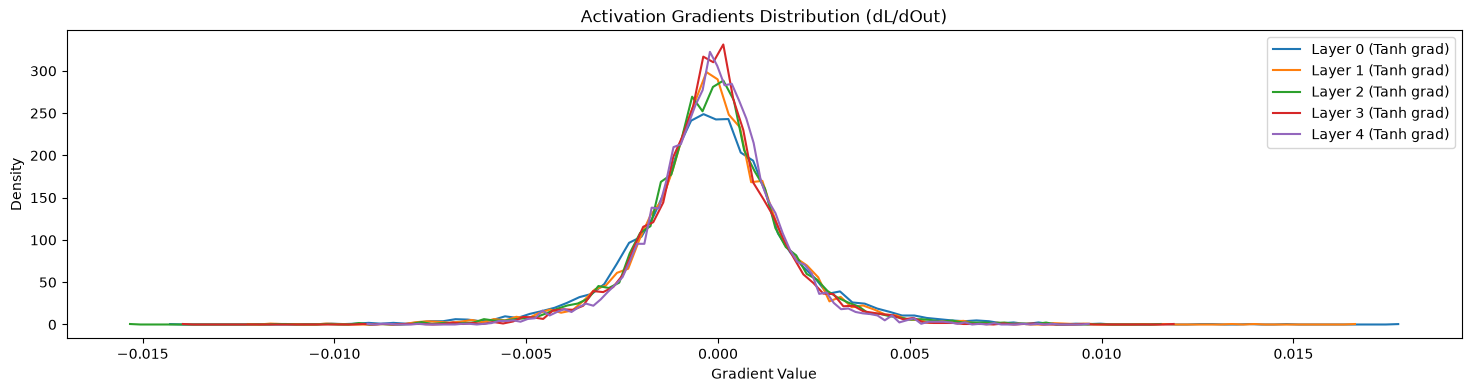

In [9]:
plot_gradient_distribution(model)

Weight (27, 10)     | Mean: -5.863883e-11 | Std: 6.505967e-03 | Grad:Data Ratio: 6.499325e-03
Weight (30, 100)    | Mean: +5.596977e-05 | Std: 6.579583e-03 | Grad:Data Ratio: 2.160188e-02
Weight (100, 100)   | Mean: -7.884359e-05 | Std: 5.929514e-03 | Grad:Data Ratio: 3.562592e-02
Weight (100, 100)   | Mean: -5.114870e-05 | Std: 5.657217e-03 | Grad:Data Ratio: 3.379279e-02
Weight (100, 100)   | Mean: -9.743319e-05 | Std: 4.925430e-03 | Grad:Data Ratio: 2.957592e-02
Weight (100, 100)   | Mean: +1.186442e-04 | Std: 4.438706e-03 | Grad:Data Ratio: 2.614327e-02
Weight (100, 27)    | Mean: -1.369942e-04 | Std: 8.539903e-03 | Grad:Data Ratio: 5.092459e-02


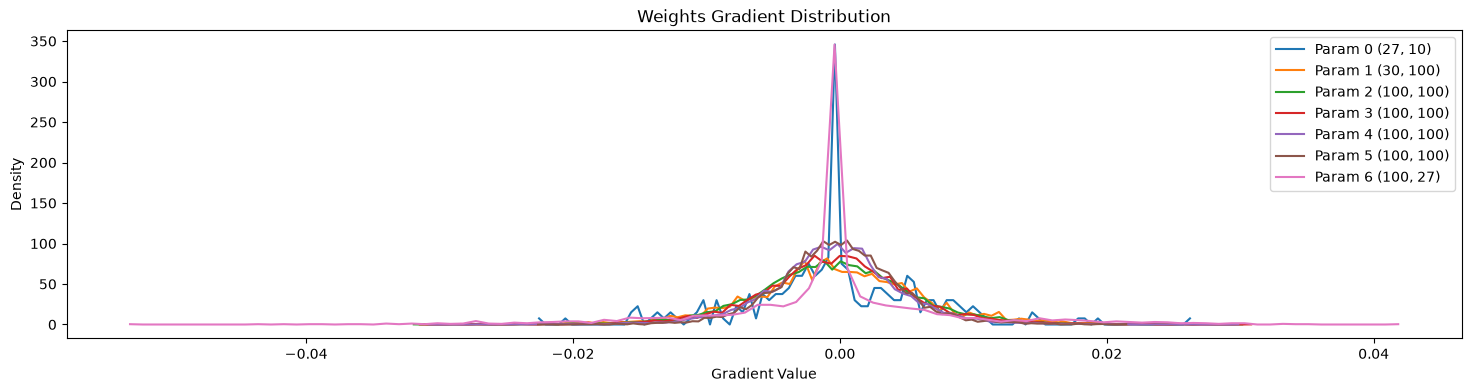

In [ ]:
plot_weights_gradient_distribution(model.parameters())

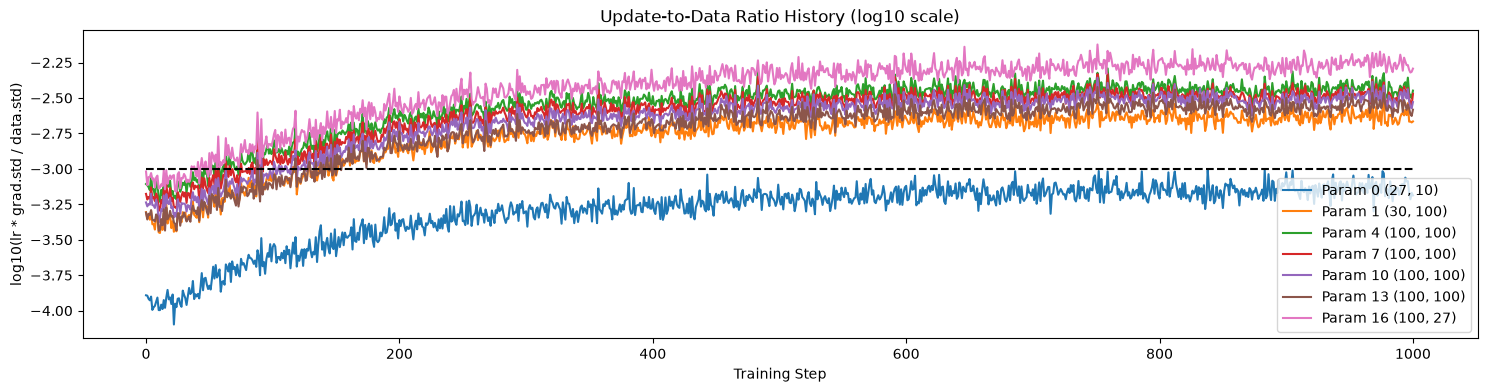

In [11]:
plot_update_to_data_ratio(ud, model.parameters())